In [3]:
import os
import shutil
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')
df_new = pd.read_csv('combined_with_hotels.csv')
print(f"New Data Shape: {df_new.shape}")

destination_dir = '/content/drive/MyDrive/NLP_Project'
destination_path = f'{destination_dir}/combined_with_hotels.csv'
os.makedirs(destination_dir, exist_ok=True)
shutil.copy('combined_with_hotels.csv', destination_path)

print(f" Data successfully saved to your Google Drive at: {destination_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
New Data Shape: (13478, 6)
 Data successfully saved to your Google Drive at: /content/drive/MyDrive/NLP_Project/combined_with_hotels.csv


In [4]:
import pandas as pd
import numpy as np
import torch
import gc
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from torch import nn

torch.cuda.empty_cache()
gc.collect()
df = pd.read_csv('/content/drive/MyDrive/NLP_Project/combined_with_hotels.csv')

texts = df['Sentences_clean'].astype(str).tolist()
labels = df['unified_sentiment'].tolist()

encoder = LabelEncoder()
encoded_labels = encoder.fit_transform(labels)
X_train, X_test, y_train, y_test = train_test_split(texts, encoded_labels, test_size=0.2, random_state=42, stratify=encoded_labels)

MODEL_NAME = "UBC-NLP/MARBERT"
print(f"Downloading Tokenizer for {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_dataset = Dataset.from_dict({"text": X_train, "label": y_train})
test_dataset = Dataset.from_dict({"text": X_test, "label": y_test})

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='weighted', zero_division=0)
    acc = accuracy_score(labels, predictions)
    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall}

print(f"Downloading {MODEL_NAME} Model...")
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)

class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss_fct = nn.CrossEntropyLoss(weight=weights_tensor)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

training_args = TrainingArguments(
    output_dir="./marbert_results",
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    num_train_epochs=4,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    fp16=True,
)

trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics,
)

print(f"Starting Training with {MODEL_NAME} on Combined Data...")
trainer.train()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/376 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=2696, training_loss=1.2242759342363396, metrics={'train_runtime': 813.5367, 'train_samples_per_second': 53.013, 'train_steps_per_second': 3.314, 'total_flos': 2836888869943296.0, 'train_loss': 1.2242759342363396, 'epoch': 4.0})

Predicting on Test Data with UBC-NLP/MARBERT...



UBC-NLP/MARBERT - Final Classification Report
              precision    recall  f1-score   support

        -1.0       0.93      0.90      0.92       914
         0.0       0.40      0.42      0.41        81
         1.0       0.94      0.96      0.95      1701

    accuracy                           0.92      2696
   macro avg       0.76      0.76      0.76      2696
weighted avg       0.92      0.92      0.92      2696



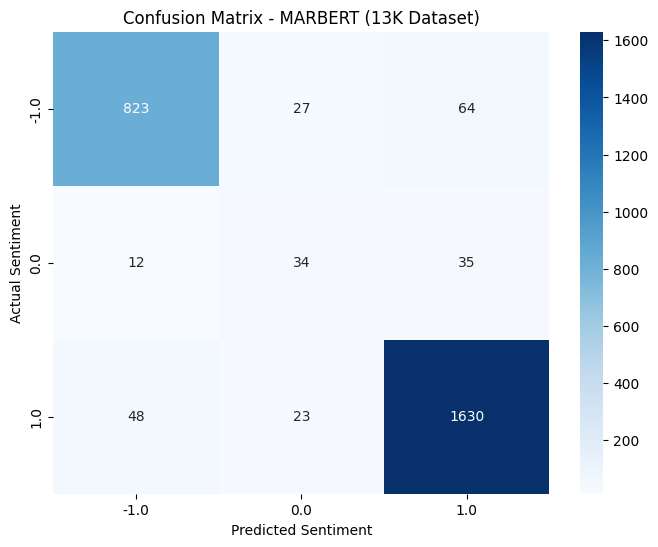

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print(f"Predicting on Test Data with {MODEL_NAME}...")
predictions_output = trainer.predict(tokenized_test)
y_pred = np.argmax(predictions_output.predictions, axis=1)
y_true = predictions_output.label_ids
target_names = [str(cls) for cls in encoder.classes_]

print("\n" + "="*50)
print(f"{MODEL_NAME} - Final Classification Report")
print("="*50)
print(classification_report(y_true, y_pred, target_names=target_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title(f'Confusion Matrix - MARBERT (13K Dataset)')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.show()